# Survey Analysis Notebook

This notebook presents the final analysis of whether a well-structured AI explanation increases perceived understanding more than it improves actual transferable understanding.

The analysis is organized as follows:
- sample construction and inclusion criteria
- descriptive statistics
- H1: perceived understanding and confidence
- H2a: transfer understanding
- H2b: stability of objective understanding
- H3: overconfidence gap

Time cutoff rationale:
- Only responses with `StartDate > 2026-03-05 19:28:00` are retained
- This cutoff corresponds to the point after the final survey adjustment, when the finalized survey link was shared
- The rule prevents earlier pre-adjustment responses from being mixed with the final study sample

Key measure wording:
- `P_Knowl` (`Q2`) = "Before today, how much did you know about how antibiotics work and why they sometimes stop working?"
- `R_con` (`Q4`) = "How confident are you that you understood the explanation you just read?"
- `Q_con` (`Q7`) = "How confident are you regarding your responses to the previous questions?"
- `No./4` (`Q13_1`) = "Of the 4 questions related to antibiotics and resistance, how many do you think you answered correctly?"

In [1]:

from pathlib import Path

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display, Markdown

ROOT = Path('.').resolve()
CUTOFF = pd.Timestamp('2026-03-05 19:28:00')

# Variable renaming used in the write-up.
RENAME_MAP = {
    'Q2': 'P_Knowl',
    'Q4': 'R_con',
    'Q7': 'Q_con',
    'Q13_1': 'No./4',
}
MEASURE_COLS = ['Q2', 'Q4', 'Q7', 'Q13_1']

# Answer key for single-choice questions.
QUIZ_SINGLE_KEY = {
    'Q3': 'Some bacteria survive and multiply, becoming resistant through natural selection',
    'Q5': "The bacteria have changed in ways that allow them to survive the antibiotic, while the patient's body remains the same",
    'Q10': 'Some insects happened to have pre-existing traits that helped them survive, and those insects reproduced at higher rates',
    'Q84': 'False',
    'Q86': "The bacteria have changed in ways that allow them to survive the antibiotic, while the patient's body remains the same",
}

# Answer key for multi-select questions.
# These are scored as exact matches against the Qualtrics export string.
QUIZ_MULTI_KEY = {
    'Q6': 'Random mutations allow some bacteria to survive the antibiotic,Surviving bacteria multiply after the weaker ones are killed (natural selection),Bacteria can share resistance genes with other bacteria',
    'Q11': 'Rotate between different types of pesticides so insects are less likely to develop resistance to any single one,Use integrated pest management (e.g., combine pesticides with natural predators or crop rotation),Avoid using pesticides when they are not truly needed to reduce selection pressure',
}

# Effort labels are text in the March 28 export, so we map them back to ordered values.
EFFORT_MAP = {
    'A little': 6,
    'A moderate amount': 7,
    'A lot': 8,
}

# Main H2 transfer items: these are the pesticide transfer questions.
TRANSFER_ITEMS = ['Q10_correct', 'Q84_correct', 'Q11_correct']

# H3 uses the exact four questions referenced by Q13_1.
H3_ITEMS = ['Q10_correct', 'Q84_correct', 'Q11_correct', 'Q86_correct']

## Helper Functions

These helper functions centralize the repeated data-cleaning and statistical operations used throughout the notebook.

In [2]:

def latest_source_csv() -> Path:
    matches = sorted(
        ROOT.glob('Why+do+AI+explanations+feel+like+understanding__*.csv'),
        key=lambda path: path.stat().st_mtime,
    )
    if not matches:
        raise FileNotFoundError('No survey export found in the project folder.')
    return matches[-1]


def finished_mask(series: pd.Series) -> pd.Series:
    values = series.astype(str).str.strip().str.lower()
    return values.isin(['true', '1', '1.0'])


def numeric_mode(series: pd.Series) -> float:
    mode = series.dropna().mode()
    if mode.empty:
        return np.nan
    return float(sorted(mode.tolist())[0])


def normalize_answer(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    return text if text else None


def cohen_d(a: pd.Series, b: pd.Series) -> float:
    a = a.dropna().astype(float)
    b = b.dropna().astype(float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    s1 = a.var(ddof=1)
    s2 = b.var(ddof=1)
    pooled_var = ((len(a) - 1) * s1 + (len(b) - 1) * s2) / (len(a) + len(b) - 2)
    if pooled_var <= 0:
        return np.nan
    return float((a.mean() - b.mean()) / np.sqrt(pooled_var))


def welch_ci(a: pd.Series, b: pd.Series, alpha: float = 0.05):
    a = a.dropna().astype(float)
    b = b.dropna().astype(float)
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan, np.nan
    m1, m2 = a.mean(), b.mean()
    v1, v2 = a.var(ddof=1), b.var(ddof=1)
    se = np.sqrt(v1 / n1 + v2 / n2)
    if se == 0:
        diff = m1 - m2
        return diff, diff
    dof_num = (v1 / n1 + v2 / n2) ** 2
    dof_den = ((v1 / n1) ** 2) / (n1 - 1) + ((v2 / n2) ** 2) / (n2 - 1)
    dof = dof_num / dof_den if dof_den > 0 else np.nan
    tcrit = stats.t.ppf(1 - alpha / 2, dof) if pd.notna(dof) else np.nan
    diff = m1 - m2
    return float(diff - tcrit * se), float(diff + tcrit * se)

## 1. Load The Latest Raw Export

The Qualtrics export stores the real variable names in the first row and metadata in the next two rows.
The metadata rows are removed before any analysis is performed.

In [3]:

source_csv = latest_source_csv()
raw = pd.read_csv(source_csv, skiprows=[1, 2])

print('Project root:', ROOT)
print('Latest raw export:', source_csv.name)
print('Raw shape:', raw.shape)

display(raw[['StartDate', 'Finished', 'Progress', 'Group1', 'Group2']].head())

Project root: /Users/oceane/Documents/BSE_T2/Behavioural Decision Making I/AI Project/AI_data_A
Latest raw export: Why+do+AI+explanations+feel+like+understanding__March+28,+2026_09.32.csv
Raw shape: (266, 40)


,StartDate,Finished,Progress,Group1,Group2
0,2026-03-02 20:08:47,True,100,NaN,NaN
1,2026-03-02 20:53:47,True,100,NaN,NaN
2,2026-03-02 21:01:45,True,100,NaN,NaN
3,2026-03-02 20:57:31,True,100,NaN,NaN
4,2026-03-03 14:12:21,True,100,NaN,NaN


## 2. Apply The Cleaning Rules

The final analytic sample is defined by three study rules:
- responses must be submitted after the March 5 cutoff
- responses must be complete
- responses must contain a valid group assignment

This step makes the sample construction explicit before any substantive analysis begins.

In [4]:

# Parse the fields needed for filtering.
raw['StartDate'] = pd.to_datetime(raw['StartDate'], errors='coerce')
raw['Progress'] = pd.to_numeric(raw['Progress'], errors='coerce')
raw['Finished_flag'] = finished_mask(raw['Finished'])

# Build each inclusion rule separately so the sample flow is transparent.
mask_after_cutoff = raw['StartDate'] > CUTOFF
mask_group_a = raw['Group1'].notna() & raw['Group2'].isna()
mask_group_b = raw['Group2'].notna() & raw['Group1'].isna()
mask_group = mask_group_a | mask_group_b
mask_complete = raw['Finished_flag'] & (raw['Progress'] == 100)

filtered = raw[mask_after_cutoff & mask_group & mask_complete].copy()
filtered['group'] = np.where(mask_group_a.loc[filtered.index], 'GroupA', 'GroupB')

sample_flow = pd.DataFrame([
    {'step': 'Raw export rows', 'n': len(raw)},
    {'step': 'After cutoff only', 'n': int(mask_after_cutoff.sum())},
    {'step': 'Valid group assignment only', 'n': int((mask_after_cutoff & mask_group).sum())},
    {'step': 'Complete responses only', 'n': int((mask_after_cutoff & mask_group & mask_complete).sum())},
])

print('Cutoff used:', CUTOFF)
display(sample_flow)
print('Final group counts:')
display(filtered.groupby('group', as_index=False).size().rename(columns={'size': 'n_complete'}))

Cutoff used: 2026-03-05 19:28:00


,step,n
0,Raw export rows,266
1,After cutoff only,239
2,Valid group assignment only,190
3,Complete responses only,170


Final group counts:


,group,n_complete
0,GroupA,85
1,GroupB,85


## Variable Labels

The renamed variables are kept explicit so the results can be read without opening the raw survey.

- `P_Knowl` (`Q2`) = "Before today, how much did you know about how antibiotics work and why they sometimes stop working?"
- `R_con` (`Q4`) = "How confident are you that you understood the explanation you just read?"
- `Q_con` (`Q7`) = "How confident are you regarding your responses to the previous questions?"
- `No./4` (`Q13_1`) = "Of the 4 questions related to antibiotics and resistance, how many do you think you answered correctly?"

## 3. Prepare The Main Analysis Variables

The focal survey variables are converted to numeric format and summarized at the group level.
The resulting table is the descriptive summary used in the results section.

In [5]:

for column in MEASURE_COLS + ['Duration (in seconds)']:
    if column in filtered.columns:
        filtered[column] = pd.to_numeric(filtered[column], errors='coerce')

analysis_df = filtered.rename(columns=RENAME_MAP).copy()
groupA = analysis_df[analysis_df['group'] == 'GroupA'].copy()
groupB = analysis_df[analysis_df['group'] == 'GroupB'].copy()


def build_group_stats(label: str, frame: pd.DataFrame) -> dict:
    row = {'group': label, 'row_count': len(frame)}
    for original_name in MEASURE_COLS:
        metric = RENAME_MAP[original_name]
        series = pd.to_numeric(frame[metric], errors='coerce').dropna().astype(float)
        row[f'{metric}_mean'] = float(series.mean()) if not series.empty else np.nan
        row[f'{metric}_median'] = float(series.median()) if not series.empty else np.nan
        row[f'{metric}_mode'] = numeric_mode(series)
    return row


group_stats = pd.DataFrame([
    build_group_stats('groupA', groupA),
    build_group_stats('groupB', groupB),
])

group_stats[group_stats.select_dtypes(include='number').columns] = group_stats.select_dtypes(include='number').round(4)

display(group_stats)

,group,row_count,P_Knowl_mean,P_Knowl_median,P_Knowl_mode,R_con_mean,R_con_median,R_con_mode,Q_con_mean,Q_con_median,Q_con_mode,No./4_mean,No./4_median,No./4_mode
0,groupA,85,4.4118,5.0,0.0,7.6000,8.0,10.0,6.9882,7.0,10.0,3.0824,3.0,3.0
1,groupB,85,4.2118,5.0,5.0,6.9176,7.0,8.0,6.4706,7.0,8.0,2.9882,3.0,3.0


## 4. Draw The Main Descriptive Figure

This figure compares the `mean`, `median`, and `mode` of the four focal measures across the two experimental groups.

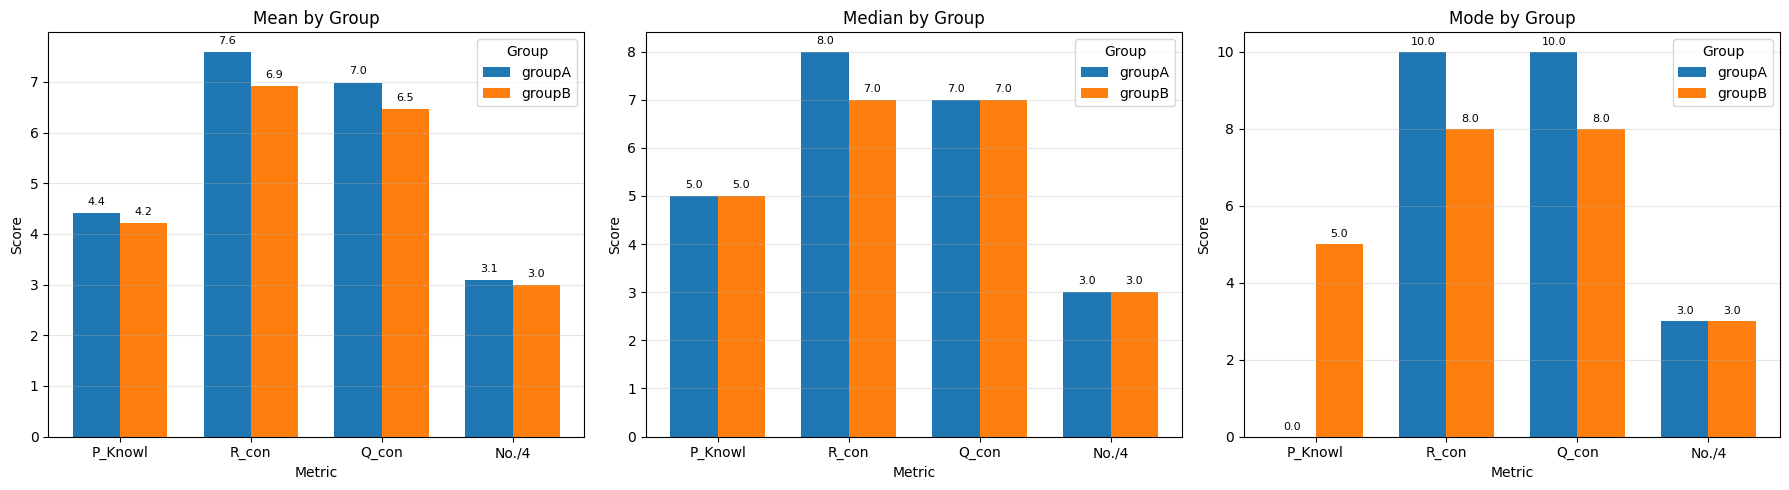

In [6]:

metrics = [RENAME_MAP[column] for column in MEASURE_COLS]
stat_names = ['mean', 'median', 'mode']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, stat_name in zip(axes, stat_names):
    cols = [f'{metric}_{stat_name}' for metric in metrics]
    chart = group_stats[['group'] + cols].set_index('group').apply(pd.to_numeric, errors='coerce')
    x = np.arange(len(metrics))
    width = 0.36
    a_vals = chart.loc['groupA', cols].values
    b_vals = chart.loc['groupB', cols].values

    bars_a = ax.bar(x - width / 2, a_vals, width, label='groupA', color='#1f77b4')
    bars_b = ax.bar(x + width / 2, b_vals, width, label='groupB', color='#ff7f0e')

    ax.set_title(f'{stat_name.capitalize()} by Group')
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Group')

    # Value labels are added so a mode of 0 does not look like missing data.
    for bars in [bars_a, bars_b]:
        for bar in bars:
            height = bar.get_height()
            if np.isnan(height):
                continue
            y = height + 0.12 if height > 0 else 0.12
            ax.text(bar.get_x() + bar.get_width() / 2, y, f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
plt.close(fig)

## 5. H1: Test Group Differences In Confidence Outcomes

H1 is evaluated as two related sub-hypotheses rather than a single pooled outcome.

- `H1a`: the AI condition increases immediate comprehension confidence after reading (`R_con`)
- `H1b`: the AI condition increases confidence in one's answers after responding (`Q_con`)

A supplementary composite is also retained:
- `Perceived_Understanding = (R_con + Q_con) / 2`

A robustness specification is also retained using:
- `Duration (in seconds) >= 250`
- `Q14 effort >= 7`

In [7]:

confidence_df = analysis_df.copy()
confidence_df['R_con'] = pd.to_numeric(confidence_df['R_con'], errors='coerce')
confidence_df['Q_con'] = pd.to_numeric(confidence_df['Q_con'], errors='coerce')
confidence_df['Perceived_Understanding'] = confidence_df[['R_con', 'Q_con']].mean(axis=1)
confidence_df['Duration_sec'] = pd.to_numeric(confidence_df['Duration (in seconds)'], errors='coerce')
mapped_effort = confidence_df['Q14'].map(EFFORT_MAP)
confidence_df['Effort'] = pd.to_numeric(mapped_effort.fillna(confidence_df['Q14']), errors='coerce')
confidence_df['group'] = confidence_df['group'].replace({'GroupA': 'groupA', 'GroupB': 'groupB'})


def analyze_confidence_sample(frame: pd.DataFrame, sample_name: str) -> pd.DataFrame:
    rows = []
    for metric in ['R_con', 'Q_con', 'Perceived_Understanding']:
        a = frame.loc[frame['group'] == 'groupA', metric].dropna().astype(float)
        b = frame.loc[frame['group'] == 'groupB', metric].dropna().astype(float)
        if len(a) < 2 or len(b) < 2:
            t_stat, p_welch, u_stat, p_mwu = np.nan, np.nan, np.nan, np.nan
        else:
            t_stat, p_welch = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit')
            u_stat, p_mwu = stats.mannwhitneyu(a, b, alternative='two-sided')
        ci_low, ci_high = welch_ci(a, b)
        rows.append({
            'sample': sample_name,
            'metric': metric,
            'groupA_n': int(a.shape[0]),
            'groupB_n': int(b.shape[0]),
            'groupA_mean': float(a.mean()),
            'groupB_mean': float(b.mean()),
            'mean_diff_A_minus_B': float(a.mean() - b.mean()),
            'ci95_low': ci_low,
            'ci95_high': ci_high,
            'cohen_d': cohen_d(a, b),
            'welch_t_stat': float(t_stat),
            'welch_p': float(p_welch),
            'mannwhitney_u': float(u_stat),
            'mannwhitney_p': float(p_mwu),
        })
    return pd.DataFrame(rows)


base_results = analyze_confidence_sample(confidence_df, 'base')
robust_results = analyze_confidence_sample(
    confidence_df[(confidence_df['Duration_sec'] >= 250) & (confidence_df['Effort'] >= 7)].copy(),
    'robust_dur_ge_250_effort_ge_7',
)

inferential_tests = pd.concat([base_results, robust_results], ignore_index=True)
inferential_tests[inferential_tests.select_dtypes(include='number').columns] = inferential_tests.select_dtypes(include='number').round(4)

display(inferential_tests)

,sample,metric,groupA_n,groupB_n,groupA_mean,groupB_mean,mean_diff_A_minus_B,ci95_low,ci95_high,cohen_d,welch_t_stat,welch_p,mannwhitney_u,mannwhitney_p
0,base,R_con,85,85,7.6000,6.9176,0.6824,-0.0205,1.3852,0.2940,1.9168,0.0570,4188.5,0.0688
1,base,Q_con,85,85,6.9882,6.4706,0.5176,-0.2322,1.2675,0.2090,1.3628,0.1748,4056.0,0.1634
2,base,Perceived_Understanding,85,85,7.2941,6.6941,0.6000,-0.0793,1.2793,0.2675,1.7439,0.0830,4140.0,0.0991
3,robust_dur_ge_250_effort_ge_7,R_con,54,48,7.9444,7.2500,0.6944,-0.0617,1.4506,0.3671,1.8248,0.0714,1535.5,0.1027
4,robust_dur_ge_250_effort_ge_7,Q_con,54,48,7.3148,6.8542,0.4606,-0.2991,1.2204,0.2429,1.2051,0.2314,1426.5,0.3773
5,robust_dur_ge_250_effort_ge_7,Perceived_Understanding,54,48,7.6296,7.0521,0.5775,-0.1114,1.2665,0.3370,1.6669,0.0992,1475.5,0.2274


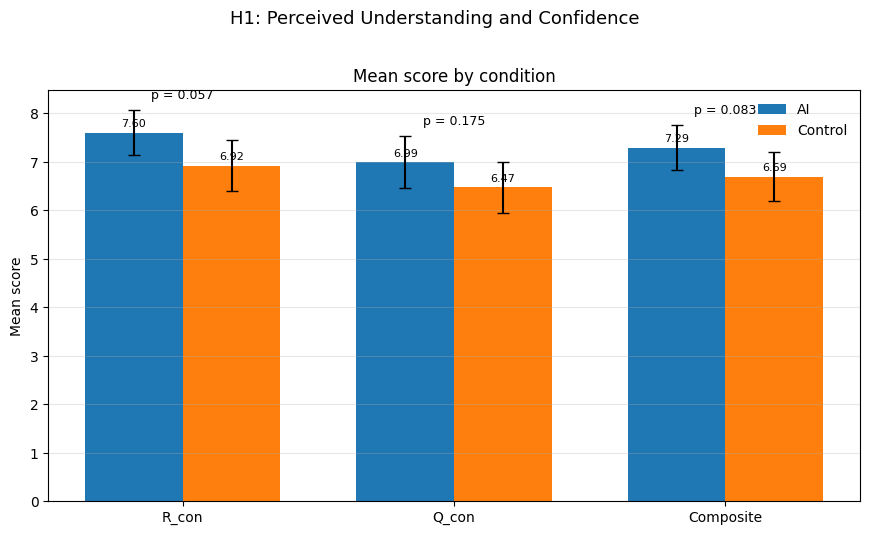

In [8]:
def mean_ci(series: pd.Series, alpha: float = 0.05):
    values = series.dropna().astype(float)
    mean = float(values.mean())
    if len(values) < 2:
        return mean, mean
    se = values.std(ddof=1) / np.sqrt(len(values))
    tcrit = stats.t.ppf(1 - alpha / 2, len(values) - 1)
    return float(mean - tcrit * se), float(mean + tcrit * se)


h1_plot_rows = []
base_h1 = inferential_tests[inferential_tests['sample'] == 'base'].copy()
for metric in ['R_con', 'Q_con', 'Perceived_Understanding']:
    for group in ['groupA', 'groupB']:
        series = confidence_df.loc[confidence_df['group'] == group, metric].dropna().astype(float)
        ci_low, ci_high = mean_ci(series)
        h1_plot_rows.append({
            'metric': metric,
            'group': group,
            'mean': float(series.mean()),
            'ci_low': ci_low,
            'ci_high': ci_high,
        })

h1_plot = pd.DataFrame(h1_plot_rows)
metric_order = ['R_con', 'Q_con', 'Perceived_Understanding']
metric_labels = ['R_con', 'Q_con', 'Composite']
x = np.arange(len(metric_order))
width = 0.36

a_plot = h1_plot[h1_plot['group'] == 'groupA'].set_index('metric').loc[metric_order]
b_plot = h1_plot[h1_plot['group'] == 'groupB'].set_index('metric').loc[metric_order]

fig, ax = plt.subplots(figsize=(8.8, 5.2))
bars_a = ax.bar(
    x - width / 2,
    a_plot['mean'],
    width,
    yerr=[a_plot['mean'] - a_plot['ci_low'], a_plot['ci_high'] - a_plot['mean']],
    capsize=4,
    color='#1f77b4',
    label='AI',
)
bars_b = ax.bar(
    x + width / 2,
    b_plot['mean'],
    width,
    yerr=[b_plot['mean'] - b_plot['ci_low'], b_plot['ci_high'] - b_plot['mean']],
    capsize=4,
    color='#ff7f0e',
    label='Control',
)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel('Mean score')
fig.suptitle('H1: Perceived Understanding and Confidence', fontsize=13, y=1.02)
ax.set_title('Mean score by condition')
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)

for idx, metric in enumerate(metric_order):
    p_value = float(base_h1.loc[base_h1['metric'] == metric, 'welch_p'].iloc[0])
    ymax = max(a_plot.loc[metric, 'ci_high'], b_plot.loc[metric, 'ci_high'])
    ax.text(idx, ymax + 0.18, f'p = {p_value:.3f}', ha='center', va='bottom', fontsize=9)

for bars in [bars_a, bars_b]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08, f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
plt.close(fig)

## H1 Interpretation

The H1 results are clearest when the two confidence outcomes are interpreted separately.

- `R_con` captures immediate confidence in understanding the explanation after reading
- `Q_con` captures confidence in one's responses after answering the questions
- `R_con` shows the stronger group difference, with `GroupA` higher than `GroupB`
- `Q_con` follows the same direction, although the separation between groups is more modest
- The combined `Perceived_Understanding` score also favors `GroupA`, but the uncertainty around the composite estimate remains fairly wide

## 6. Score The Objective Questions

The answer key is applied directly to the March 28 export.

Item roles in the later analyses:
- `Q10`, `Q84`, and `Q11` are treated as the core transfer items for H2a because they require participants to apply the resistance logic to the pesticide case
- `Q5` and `Q86` ask the same antibiotic-resistance concept at two different points in the survey, so they are reserved for H2b as a stability check
- `Q13_1` asks participants how many of four items they think they answered correctly; in this survey, those four items are `Q10`, `Q84`, `Q11`, and `Q86`, so H3 compares that self-estimate against the matching four-item objective score

In [9]:

scored = filtered.copy()

# Score all single-choice questions.
for question, key in QUIZ_SINGLE_KEY.items():
    scored[f'{question}_correct'] = scored[question].apply(normalize_answer).apply(
        lambda value: 1 if value == key else (0 if value is not None else np.nan)
    )

# Score the multi-select questions as exact matches.
for question, key in QUIZ_MULTI_KEY.items():
    scored[f'{question}_correct'] = scored[question].apply(normalize_answer).apply(
        lambda value: 1 if value == key else (0 if value is not None else np.nan)
    )

question_rate_summary = pd.DataFrame([
    {
        'group': group,
        'Q10_correct_pct': round(frame['Q10_correct'].mean() * 100, 2),
        'Q84_correct_pct': round(frame['Q84_correct'].mean() * 100, 2),
        'Q11_correct_pct': round(frame['Q11_correct'].mean() * 100, 2),
        'Q86_correct_pct': round(frame['Q86_correct'].mean() * 100, 2),
    }
    for group, frame in scored.groupby('group')
])

display(question_rate_summary)

,group,Q10_correct_pct,Q84_correct_pct,Q11_correct_pct,Q86_correct_pct
0,GroupA,12.94,24.71,36.47,70.59
1,GroupB,11.76,35.29,34.12,67.06


## 7. H2a: Transfer Questions Only (`Q10`, `Q84`, `Q11`)

This section reports the main H2a specification used in the write-up.

In [10]:

h2_df = scored.copy()
h2_df['group_ai'] = (h2_df['group'] == 'GroupA').astype(int)
h2_df['transfer_total'] = h2_df[TRANSFER_ITEMS].sum(axis=1)
h2_df['transfer_rate'] = h2_df['transfer_total'] / 3.0

question_rows = []
for question in TRANSFER_ITEMS:
    a = h2_df.loc[h2_df['group'] == 'GroupA', question].dropna()
    b = h2_df.loc[h2_df['group'] == 'GroupB', question].dropna()
    a_correct = int((a == 1).sum())
    a_incorrect = int((a == 0).sum())
    b_correct = int((b == 1).sum())
    b_incorrect = int((b == 0).sum())
    table = np.array([[a_correct, a_incorrect], [b_correct, b_incorrect]])
    odds_ratio, p_fisher = stats.fisher_exact(table, alternative='two-sided')
    try:
        chi2_stat, p_chi2, _, _ = stats.chi2_contingency(table, correction=False)
    except ValueError:
        chi2_stat, p_chi2 = np.nan, np.nan
    question_rows.append({
        'question': question,
        'groupA_n': int(len(a)),
        'groupB_n': int(len(b)),
        'groupA_correct_rate': float(a.mean()),
        'groupB_correct_rate': float(b.mean()),
        'rate_diff_A_minus_B': float(a.mean() - b.mean()),
        'chi2_stat': float(chi2_stat),
        'chi2_p': float(p_chi2),
        'fisher_odds_ratio': float(odds_ratio),
        'fisher_p': float(p_fisher),
        'groupA_correct_n': a_correct,
        'groupB_correct_n': b_correct,
    })

h2_question_tests = pd.DataFrame(question_rows)
h2_question_tests[h2_question_tests.select_dtypes(include='number').columns] = h2_question_tests.select_dtypes(include='number').round(4)

a_total = h2_df.loc[h2_df['group'] == 'GroupA', 'transfer_total'].dropna()
b_total = h2_df.loc[h2_df['group'] == 'GroupB', 'transfer_total'].dropna()
_, transfer_welch_p = stats.ttest_ind(a_total, b_total, equal_var=False)
_, transfer_mwu_p = stats.mannwhitneyu(a_total, b_total, alternative='two-sided')

# Regression model: transfer_total ~ Q2 + group
reg = h2_df[['transfer_total', 'Q2', 'group_ai']].dropna().copy()
y = reg['transfer_total'].values.astype(float)
x = np.column_stack([np.ones(len(reg)), reg['Q2'].values.astype(float), reg['group_ai'].values.astype(float)])
xtx_inv = np.linalg.inv(x.T @ x)
beta = xtx_inv @ (x.T @ y)
y_hat = x @ beta
resid = y - y_hat
n = len(y)
k = x.shape[1]
df_resid = n - k
rss = float((resid ** 2).sum())
tss = float(((y - y.mean()) ** 2).sum())
r_squared = 1 - rss / tss if tss > 0 else np.nan
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / df_resid if df_resid > 0 else np.nan
sigma2 = rss / df_resid
cov_beta = sigma2 * xtx_inv
std_err = np.sqrt(np.diag(cov_beta))
t_values = beta / std_err
p_values = 2 * (1 - stats.t.cdf(np.abs(t_values), df_resid))

h2_model_summary = pd.DataFrame([{
    'n': n,
    'r_squared': round(r_squared, 4),
    'adj_r_squared': round(adj_r_squared, 4),
    'welch_t_transfer_total_p': round(float(transfer_welch_p), 4),
    'mannwhitney_transfer_total_p': round(float(transfer_mwu_p), 4),
    'groupA_transfer_total_mean': round(float(a_total.mean()), 4),
    'groupB_transfer_total_mean': round(float(b_total.mean()), 4),
    'groupA_transfer_rate_pct': round(float(a_total.mean() / 3 * 100), 2),
    'groupB_transfer_rate_pct': round(float(b_total.mean() / 3 * 100), 2),
    'q2_coef': round(float(beta[1]), 4),
    'q2_p': round(float(p_values[1]), 4),
    'groupA_coef': round(float(beta[2]), 4),
    'groupA_p': round(float(p_values[2]), 4),
}])


display(h2_question_tests)
display(h2_model_summary)

,question,groupA_n,groupB_n,groupA_correct_rate,groupB_correct_rate,rate_diff_A_minus_B,chi2_stat,chi2_p,fisher_odds_ratio,fisher_p,groupA_correct_n,groupB_correct_n
0,Q10_correct,85,85,0.1294,0.1176,0.0118,0.0543,0.8157,1.1149,1.0000,11,10
1,Q84_correct,85,85,0.2471,0.3529,-0.1059,2.2689,0.1320,0.6016,0.1803,21,30
2,Q11_correct,85,85,0.3647,0.3412,0.0235,0.1030,0.7482,1.1086,0.8726,31,29


,n,r_squared,adj_r_squared,welch_t_transfer_total_p,mannwhitney_transfer_total_p,groupA_transfer_total_mean,groupB_transfer_total_mean,groupA_transfer_rate_pct,groupB_transfer_rate_pct,q2_coef,q2_p,groupA_coef,groupA_p
0,170,0.0021,-0.0099,0.5949,0.8625,0.7412,0.8118,24.71,27.06,-0.0057,0.799,-0.0694,0.602


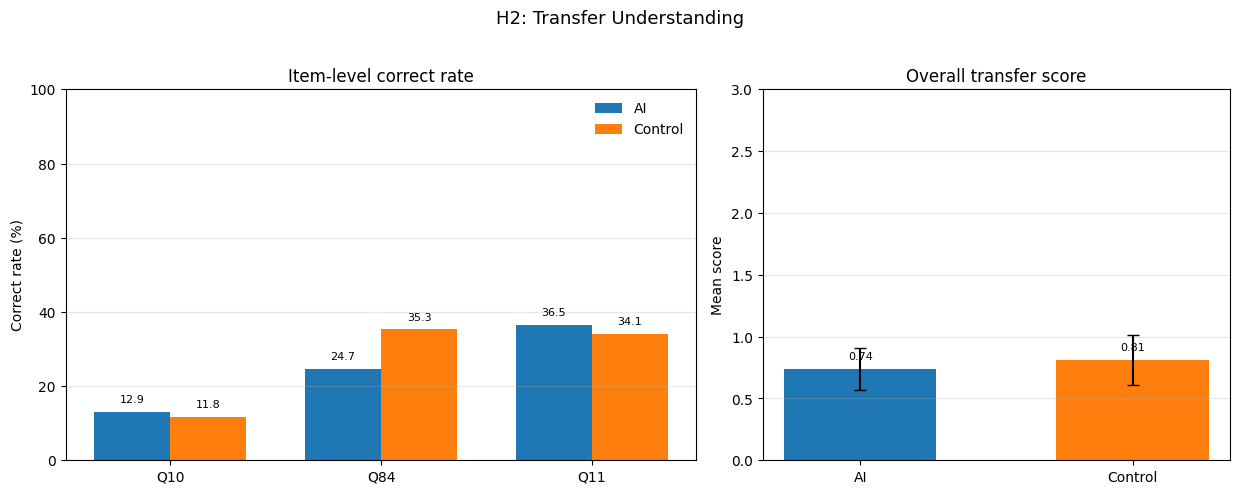

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={'width_ratios': [1.35, 1]})

labels = ['Q10', 'Q84', 'Q11']
a_rates = [h2_df.loc[h2_df['group'] == 'GroupA', item].mean() * 100 for item in TRANSFER_ITEMS]
b_rates = [h2_df.loc[h2_df['group'] == 'GroupB', item].mean() * 100 for item in TRANSFER_ITEMS]
x_pos = np.arange(len(labels))
width = 0.36

bars_a = axes[0].bar(x_pos - width / 2, a_rates, width, color='#1f77b4', label='AI')
bars_b = axes[0].bar(x_pos + width / 2, b_rates, width, color='#ff7f0e', label='Control')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Correct rate (%)')
fig.suptitle('H2: Transfer Understanding', fontsize=13, y=1.02)
axes[0].set_title('Item-level correct rate')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(frameon=False)

for bars in [bars_a, bars_b]:
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f'{bar.get_height():.1f}',
            ha='center',
            va='bottom',
            fontsize=8,
        )

transfer_plot_rows = []
for group in ['GroupA', 'GroupB']:
    series = h2_df.loc[h2_df['group'] == group, 'transfer_total'].dropna().astype(float)
    ci_low, ci_high = mean_ci(series)
    transfer_plot_rows.append({
        'group': group,
        'mean': float(series.mean()),
        'ci_low': ci_low,
        'ci_high': ci_high,
    })

transfer_plot = pd.DataFrame(transfer_plot_rows).set_index('group').loc[['GroupA', 'GroupB']]
group_x = np.arange(2)
transfer_bars = axes[1].bar(
    group_x,
    transfer_plot['mean'],
    width=0.56,
    yerr=[transfer_plot['mean'] - transfer_plot['ci_low'], transfer_plot['ci_high'] - transfer_plot['mean']],
    capsize=4,
    color=['#1f77b4', '#ff7f0e'],
)
axes[1].set_xticks(group_x)
axes[1].set_xticklabels(['AI', 'Control'])
axes[1].set_ylim(0, 3)
axes[1].set_ylabel('Mean score')
axes[1].set_title('Overall transfer score')
axes[1].grid(axis='y', alpha=0.3)

for bar in transfer_bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.06,
        f'{bar.get_height():.2f}',
        ha='center',
        va='bottom',
        fontsize=8,
    )

plt.tight_layout()
plt.show()
plt.close(fig)

## H2a Interpretation

- Transfer performance was very similar across conditions
- Descriptively, `GroupB` was slightly higher than `GroupA` on the combined transfer score
- The group difference was small relative to the surrounding uncertainty, so the main conclusion is that transfer understanding remained broadly comparable across conditions
- The regression model (`transfer_total ~ Q2 + group`) points in the same direction: neither prior knowledge nor condition showed a clear relationship with transfer performance in this sample

## 8. H2b: Stability Check (`Q5` vs `Q86`)

`Q5` and `Q86` ask the same antibiotic-resistance concept at two different points in the survey.

This makes them useful as a short-term stability check:
- if understanding is stable, correct responses should be maintained when the concept reappears
- if understanding is fragile, correct responses may fall when the same concept is asked again later

In [12]:
stability_rows = []

for group, frame in scored.groupby('group'):
    q5 = frame['Q5_correct'].dropna()
    q86 = frame['Q86_correct'].dropna()

    correct_to_wrong = int(((q5 == 1) & (q86 == 0)).sum())
    wrong_to_correct = int(((q5 == 0) & (q86 == 1)).sum())
    discordant_pairs = correct_to_wrong + wrong_to_correct
    if discordant_pairs > 0:
        mcnemar_p = min(
            1.0,
            2 * stats.binomtest(min(correct_to_wrong, wrong_to_correct), discordant_pairs, 0.5, alternative='two-sided').pvalue,
        )
    else:
        mcnemar_p = np.nan

    stability_rows.append({
        'group': group,
        'n': int(len(frame)),
        'Q5_correct_pct': round(float(q5.mean() * 100), 2),
        'Q86_correct_pct': round(float(q86.mean() * 100), 2),
        'change_pp': round(float((q86.mean() - q5.mean()) * 100), 2),
        'correct_to_wrong': correct_to_wrong,
        'wrong_to_correct': wrong_to_correct,
        'mcnemar_exact_p': round(float(mcnemar_p), 4) if pd.notna(mcnemar_p) else np.nan,
    })

stability_summary = pd.DataFrame(stability_rows)

scored['stability_change'] = scored['Q86_correct'] - scored['Q5_correct']
a_change = scored.loc[scored['group'] == 'GroupA', 'stability_change'].dropna()
b_change = scored.loc[scored['group'] == 'GroupB', 'stability_change'].dropna()
_, stability_welch_p = stats.ttest_ind(a_change, b_change, equal_var=False)
_, stability_mwu_p = stats.mannwhitneyu(a_change, b_change, alternative='two-sided')

between_group_change = pd.DataFrame([
    {
        'groupA_mean_change': round(float(a_change.mean()), 4),
        'groupB_mean_change': round(float(b_change.mean()), 4),
        'diff_A_minus_B': round(float(a_change.mean() - b_change.mean()), 4),
        'welch_p': round(float(stability_welch_p), 4),
        'mannwhitney_p': round(float(stability_mwu_p), 4),
    }
])

display(stability_summary)
display(between_group_change)

,group,n,Q5_correct_pct,Q86_correct_pct,change_pp,correct_to_wrong,wrong_to_correct,mcnemar_exact_p
0,GroupA,85,85.88,70.59,-15.29,16,3,0.0089
1,GroupB,85,77.65,67.06,-10.59,12,3,0.0703


,groupA_mean_change,groupB_mean_change,diff_A_minus_B,welch_p,mannwhitney_p
0,-0.1529,-0.1059,-0.0471,0.4765,0.4637


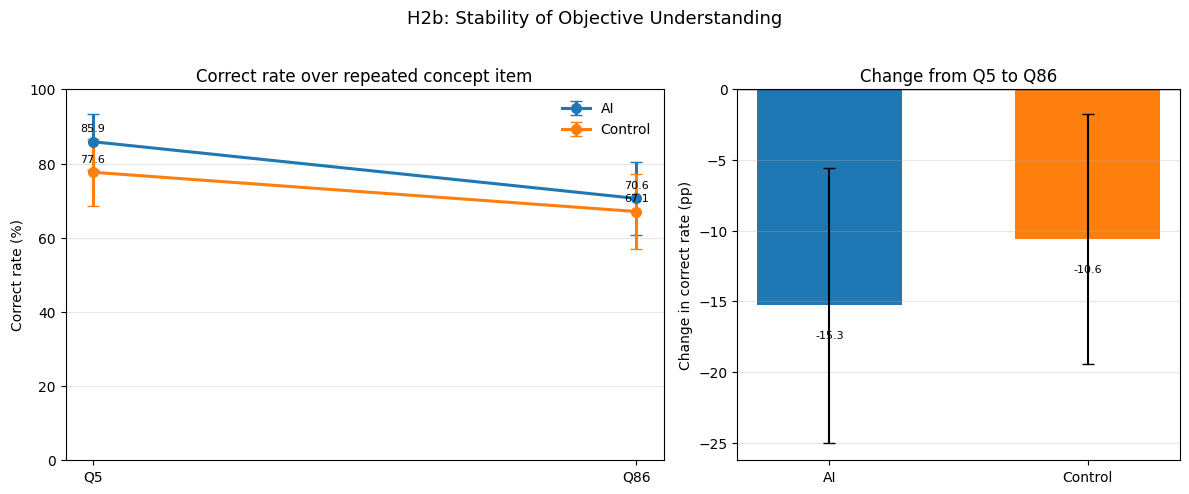

In [13]:
h2b_rate_rows = []
for question in ['Q5_correct', 'Q86_correct']:
    for group in ['GroupA', 'GroupB']:
        series = scored.loc[scored['group'] == group, question].dropna().astype(float)
        ci_low, ci_high = mean_ci(series)
        h2b_rate_rows.append({
            'question': question,
            'group': group,
            'mean_pct': float(series.mean() * 100),
            'ci_low_pct': float(ci_low * 100),
            'ci_high_pct': float(ci_high * 100),
        })

h2b_rate_plot = pd.DataFrame(h2b_rate_rows)
h2b_change_rows = []
for group in ['GroupA', 'GroupB']:
    series = scored.loc[scored['group'] == group, 'stability_change'].dropna().astype(float)
    ci_low, ci_high = mean_ci(series)
    h2b_change_rows.append({
        'group': group,
        'mean_change_pp': float(series.mean() * 100),
        'ci_low_pp': float(ci_low * 100),
        'ci_high_pp': float(ci_high * 100),
    })

h2b_change_plot = pd.DataFrame(h2b_change_rows).set_index('group').loc[['GroupA', 'GroupB']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={'width_ratios': [1.35, 1]})
fig.suptitle('H2b: Stability of Objective Understanding', fontsize=13, y=1.02)

groups = ['GroupA', 'GroupB']
group_labels = ['AI', 'Control']
question_order = ['Q5_correct', 'Q86_correct']
question_labels = ['Q5', 'Q86']
colors = {'GroupA': '#1f77b4', 'GroupB': '#ff7f0e'}

for group, label in zip(groups, group_labels):
    frame = h2b_rate_plot[h2b_rate_plot['group'] == group].set_index('question').loc[question_order]
    x = np.arange(len(question_order))
    y = frame['mean_pct'].values
    yerr = np.vstack([
        y - frame['ci_low_pct'].values,
        frame['ci_high_pct'].values - y,
    ])
    axes[0].errorbar(x, y, yerr=yerr, marker='o', linewidth=2.2, markersize=7, color=colors[group], capsize=4, label=label)
    for xi, yi in zip(x, y):
        axes[0].text(xi, yi + 2.2, f'{yi:.1f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(np.arange(len(question_labels)))
axes[0].set_xticklabels(question_labels)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Correct rate (%)')
axes[0].set_title('Correct rate over repeated concept item')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(frameon=False)

change_x = np.arange(2)
change_vals = h2b_change_plot['mean_change_pp'].values
change_err = np.vstack([
    change_vals - h2b_change_plot['ci_low_pp'].values,
    h2b_change_plot['ci_high_pp'].values - change_vals,
])
change_bars = axes[1].bar(
    change_x,
    change_vals,
    width=0.56,
    yerr=change_err,
    capsize=4,
    color=[colors['GroupA'], colors['GroupB']],
)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xticks(change_x)
axes[1].set_xticklabels(group_labels)
axes[1].set_ylabel('Change in correct rate (pp)')
axes[1].set_title('Change from Q5 to Q86')
axes[1].grid(axis='y', alpha=0.3)

for bar, value in zip(change_bars, change_vals):
    va = 'top' if value < 0 else 'bottom'
    offset = -1.8 if value < 0 else 1.2
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + offset, f'{value:.1f}', ha='center', va=va, fontsize=8)

plt.tight_layout()
plt.show()
plt.close(fig)


## H2b Interpretation

- Both groups performed worse when the same antibiotic-resistance concept reappeared later in the survey
- Descriptively, the decline was larger in `GroupA` than in `GroupB`
- The within-group drop is clearer in `GroupA` than in `GroupB`
- The between-group estimate is fairly uncertain, so H2b is best read as a directional pattern rather than a decisive separation between conditions

## 9. H3: The Overconfidence Gap

H3 asks whether the fluent AI condition produces a larger mismatch between perceived and actual performance.

The main H3 measure uses the self-estimated four-item score in `Q13_1` and compares it against the actual score on the same four questions:
- self-estimated rate = `Q13_1 / 4`
- actual four-item rate = `(Q10_correct + Q84_correct + Q11_correct + Q86_correct) / 4`
- overconfidence gap = `self-estimated rate - actual four-item rate`

This is the preferred H3 algorithm because the self-report and the objective score refer to the same item set.

In [14]:
h3_df = scored.copy()

# Q13_1 asks for a self-estimate over the same four questions listed in H3_ITEMS.
h3_df['self_estimated_rate'] = pd.to_numeric(h3_df['Q13_1'], errors='coerce') / 4.0
h3_df['actual_four_item_rate'] = h3_df[H3_ITEMS].mean(axis=1)
h3_df['overconfidence_gap'] = h3_df['self_estimated_rate'] - h3_df['actual_four_item_rate']

h3_rows = []
for group, frame in h3_df.groupby('group'):
    gap = frame['overconfidence_gap'].dropna().astype(float)
    one_sample = stats.ttest_1samp(gap, 0.0)
    h3_rows.append({
        'group': group,
        'n': int(len(gap)),
        'self_estimated_rate': float(frame['self_estimated_rate'].mean()),
        'actual_four_item_rate': float(frame['actual_four_item_rate'].mean()),
        'gap_mean': float(gap.mean()),
        'gap_sd': float(gap.std(ddof=1)),
        'one_sample_t': float(one_sample.statistic),
        'one_sample_p': format(float(one_sample.pvalue), '.4e'),
    })

h3_summary = pd.DataFrame(h3_rows)

a_gap = h3_df.loc[h3_df['group'] == 'GroupA', 'overconfidence_gap'].dropna().astype(float)
b_gap = h3_df.loc[h3_df['group'] == 'GroupB', 'overconfidence_gap'].dropna().astype(float)
h3_welch = stats.ttest_ind(a_gap, b_gap, equal_var=False)
h3_mwu = stats.mannwhitneyu(a_gap, b_gap, alternative='two-sided')

h3_between = pd.DataFrame([{
    'groupA_gap_mean': float(a_gap.mean()),
    'groupB_gap_mean': float(b_gap.mean()),
    'diff_A_minus_B': float(a_gap.mean() - b_gap.mean()),
    'welch_t': float(h3_welch.statistic),
    'welch_p': float(h3_welch.pvalue),
    'mannwhitney_u': float(h3_mwu.statistic),
    'mannwhitney_p': float(h3_mwu.pvalue),
}])

h3_summary[h3_summary.select_dtypes(include='number').columns] = h3_summary.select_dtypes(include='number').round(4)
h3_between[h3_between.select_dtypes(include='number').columns] = h3_between.select_dtypes(include='number').round(4)

display(h3_summary)
display(h3_between)

,group,n,self_estimated_rate,actual_four_item_rate,gap_mean,gap_sd,one_sample_t,one_sample_p
0,GroupA,85,0.7706,0.3618,0.4088,0.2934,12.8466,1.5923e-21
1,GroupB,85,0.7471,0.3706,0.3765,0.3077,11.2802,1.6758e-18


,groupA_gap_mean,groupB_gap_mean,diff_A_minus_B,welch_t,welch_p,mannwhitney_u,mannwhitney_p
0,0.4088,0.3765,0.0324,0.7016,0.4839,3768.0,0.6182


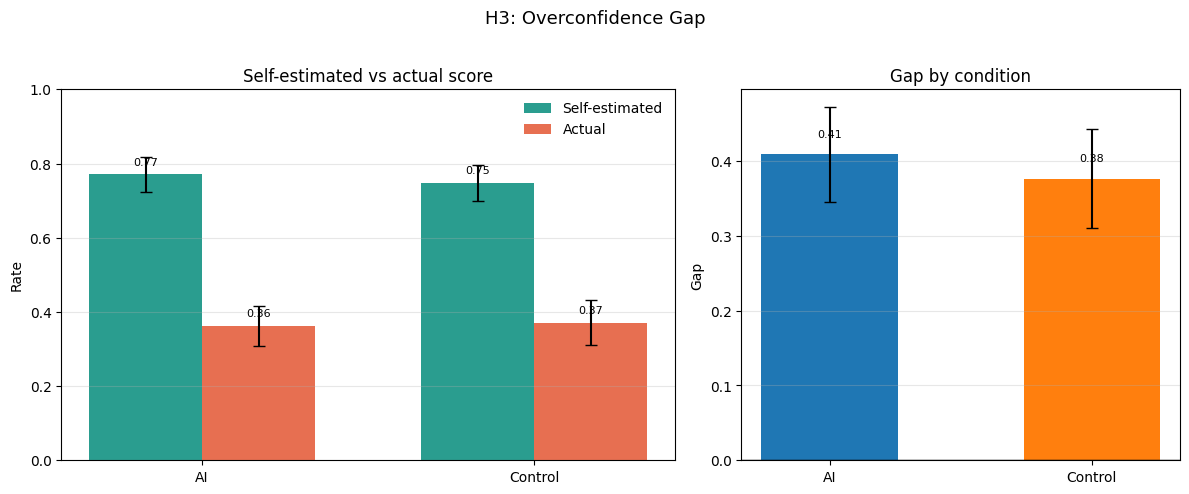

In [15]:
h3_level_rows = []
for metric in ['self_estimated_rate', 'actual_four_item_rate']:
    for group in ['GroupA', 'GroupB']:
        series = h3_df.loc[h3_df['group'] == group, metric].dropna().astype(float)
        ci_low, ci_high = mean_ci(series)
        h3_level_rows.append({
            'metric': metric,
            'group': group,
            'mean': float(series.mean()),
            'ci_low': ci_low,
            'ci_high': ci_high,
        })

h3_level_plot = pd.DataFrame(h3_level_rows)
h3_gap_rows = []
for group in ['GroupA', 'GroupB']:
    series = h3_df.loc[h3_df['group'] == group, 'overconfidence_gap'].dropna().astype(float)
    ci_low, ci_high = mean_ci(series)
    h3_gap_rows.append({
        'group': group,
        'mean': float(series.mean()),
        'ci_low': ci_low,
        'ci_high': ci_high,
    })

h3_gap_plot = pd.DataFrame(h3_gap_rows).set_index('group').loc[['GroupA', 'GroupB']]
h3_level_plot = h3_level_plot.set_index(['metric', 'group'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={'width_ratios': [1.4, 1]})

groups = ['GroupA', 'GroupB']
group_labels = ['AI', 'Control']
x = np.arange(len(groups))
width = 0.34
self_vals = h3_level_plot.loc[('self_estimated_rate', slice(None)), :].reset_index().set_index('group').loc[groups]
actual_vals = h3_level_plot.loc[('actual_four_item_rate', slice(None)), :].reset_index().set_index('group').loc[groups]

bars_self = axes[0].bar(
    x - width / 2,
    self_vals['mean'],
    width,
    yerr=[self_vals['mean'] - self_vals['ci_low'], self_vals['ci_high'] - self_vals['mean']],
    capsize=4,
    color='#2a9d8f',
    label='Self-estimated',
)
bars_actual = axes[0].bar(
    x + width / 2,
    actual_vals['mean'],
    width,
    yerr=[actual_vals['mean'] - actual_vals['ci_low'], actual_vals['ci_high'] - actual_vals['mean']],
    capsize=4,
    color='#e76f51',
    label='Actual',
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(group_labels)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Rate')
fig.suptitle('H3: Overconfidence Gap', fontsize=13, y=1.02)
axes[0].set_title('Self-estimated vs actual score')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(frameon=False)

for bars in [bars_self, bars_actual]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

gap_x = np.arange(len(groups))
gap_vals = h3_gap_plot['mean']
gap_err = [gap_vals - h3_gap_plot['ci_low'], h3_gap_plot['ci_high'] - gap_vals]
gap_bars = axes[1].bar(gap_x, gap_vals, width=0.52, yerr=gap_err, capsize=4, color=['#1f77b4', '#ff7f0e'])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xticks(gap_x)
axes[1].set_xticklabels(group_labels)
axes[1].set_ylabel('Gap')
axes[1].set_title('Gap by condition')
axes[1].grid(axis='y', alpha=0.3)

for bar in gap_bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
plt.close(fig)

## H3 Interpretation

- Both groups showed a substantial positive overconfidence gap, meaning participants believed they had answered more of the four items correctly than they actually had
- Descriptively, the gap was larger in `GroupA` than in `GroupB`
- This pattern follows the predicted direction of H3, although the amount of group separation remains limited relative to the uncertainty in the estimate

## 10. Exploratory Language Heterogeneity

This section examines whether the main patterns differ by `UserLanguage`.

The language analysis is exploratory and should be interpreted cautiously because subgroup sizes are smaller than in the full sample, especially for English.

The focus is on five outcomes:
- `R_con`
- `Q_con`
- `transfer_total`
- `stability_change`
- `overconfidence_gap`

The analysis is reported in two steps:
- descriptive AI vs Control comparisons within each language
- a `group × language` interaction test for each outcome


In [16]:
lang_df = scored.copy()
lang_df['R_con'] = pd.to_numeric(lang_df['Q4'], errors='coerce')
lang_df['Q_con'] = pd.to_numeric(lang_df['Q7'], errors='coerce')
lang_df['transfer_total'] = lang_df[['Q10_correct', 'Q84_correct', 'Q11_correct']].sum(axis=1)
lang_df['stability_change'] = lang_df['Q86_correct'] - lang_df['Q5_correct']
lang_df['Q13_1'] = pd.to_numeric(lang_df['Q13_1'], errors='coerce')
lang_df['overconfidence_gap'] = lang_df['Q13_1'] / 4.0 - lang_df[['Q10_correct', 'Q84_correct', 'Q11_correct', 'Q86_correct']].mean(axis=1)

language_counts = pd.crosstab(lang_df['UserLanguage'], lang_df['group']).rename_axis('language').reset_index()
display(language_counts)

language_outcomes = ['R_con', 'Q_con', 'transfer_total', 'stability_change', 'overconfidence_gap']
comparison_rows = []
for outcome in language_outcomes:
    for language in sorted(lang_df['UserLanguage'].dropna().unique()):
        sub = lang_df[lang_df['UserLanguage'] == language]
        ai = sub.loc[sub['group'] == 'GroupA', outcome].dropna().astype(float)
        control = sub.loc[sub['group'] == 'GroupB', outcome].dropna().astype(float)
        _, p_val = stats.ttest_ind(ai, control, equal_var=False)
        comparison_rows.append({
            'outcome': outcome,
            'language': language,
            'AI_n': int(len(ai)),
            'Control_n': int(len(control)),
            'AI_mean': float(ai.mean()),
            'Control_mean': float(control.mean()),
            'diff_AI_minus_Control': float(ai.mean() - control.mean()),
            'welch_p': float(p_val),
        })

language_comparisons = pd.DataFrame(comparison_rows)
language_comparisons[language_comparisons.select_dtypes(include='number').columns] = language_comparisons.select_dtypes(include='number').round(4)
display(language_comparisons)

interaction_rows = []
for outcome in language_outcomes:
    sub = lang_df[['group', 'UserLanguage', outcome]].dropna().copy()
    y = sub[outcome].astype(float).to_numpy()
    g = (sub['group'] == 'GroupA').astype(float).to_numpy()
    es = (sub['UserLanguage'] == 'ES').astype(float).to_numpy()
    zh = (sub['UserLanguage'] == 'ZH-S').astype(float).to_numpy()

    x_reduced = np.column_stack([np.ones(len(sub)), g, es, zh])
    x_full = np.column_stack([np.ones(len(sub)), g, es, zh, g * es, g * zh])

    beta_r, *_ = np.linalg.lstsq(x_reduced, y, rcond=None)
    beta_f, *_ = np.linalg.lstsq(x_full, y, rcond=None)
    resid_r = y - x_reduced @ beta_r
    resid_f = y - x_full @ beta_f
    rss_r = float((resid_r ** 2).sum())
    rss_f = float((resid_f ** 2).sum())
    df_num = x_full.shape[1] - x_reduced.shape[1]
    df_den = len(y) - x_full.shape[1]
    f_stat = ((rss_r - rss_f) / df_num) / (rss_f / df_den)
    p_val = 1 - stats.f.cdf(f_stat, df_num, df_den)

    interaction_rows.append({
        'outcome': outcome,
        'interaction_F': float(f_stat),
        'interaction_p': float(p_val),
    })

language_interactions = pd.DataFrame(interaction_rows)
language_interactions[language_interactions.select_dtypes(include='number').columns] = language_interactions.select_dtypes(include='number').round(4)
display(language_interactions)


group,language,GroupA,GroupB
0,EN,16,13
1,ES,38,39
2,ZH-S,31,33


,outcome,language,AI_n,Control_n,AI_mean,Control_mean,diff_AI_minus_Control,welch_p
0,R_con,EN,16,13,8.1250,7.6154,0.5096,0.4735
1,R_con,ES,38,39,8.1579,7.6410,0.5169,0.2566
2,R_con,ZH-S,31,33,6.6452,5.7879,0.8573,0.1798
3,Q_con,EN,16,13,7.3750,5.6923,1.6827,0.0590
4,Q_con,ES,38,39,7.7368,7.5641,0.1727,0.6903
5,Q_con,ZH-S,31,33,5.8710,5.4848,0.3861,0.5813
6,transfer_total,EN,16,13,0.9375,0.7692,0.1683,0.6526
7,transfer_total,ES,38,39,0.6842,0.7179,-0.0337,0.8640
8,transfer_total,ZH-S,31,33,0.7097,0.9394,-0.2297,0.2565
9,stability_change,EN,16,13,-0.1250,-0.2308,0.1058,0.4840


,outcome,interaction_F,interaction_p
0,R_con,0.1210,0.8861
1,Q_con,1.1444,0.3209
2,transfer_total,0.5570,0.5740
3,stability_change,0.7553,0.4715
4,overconfidence_gap,0.3899,0.6777


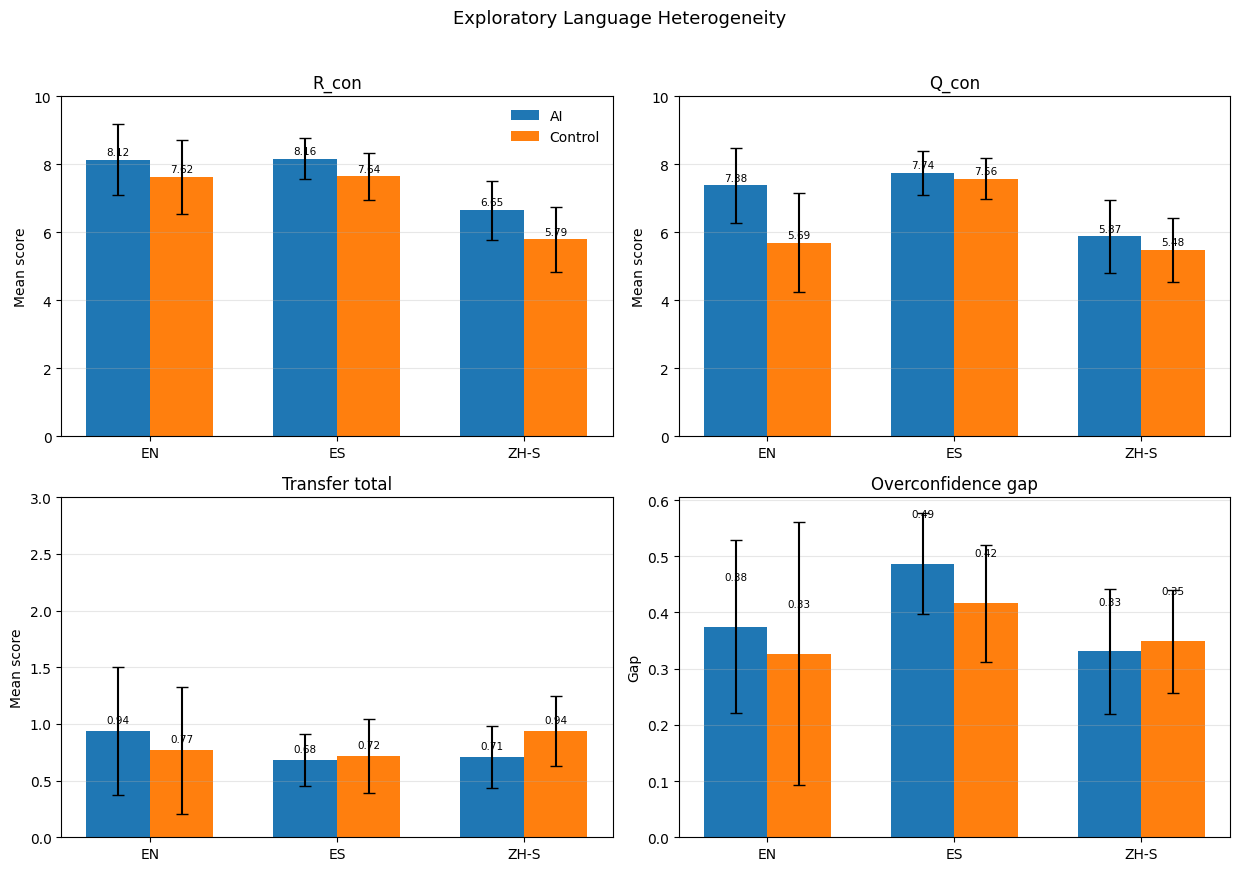

In [17]:
language_plot_outcomes = [
    ('R_con', 'R_con'),
    ('Q_con', 'Q_con'),
    ('transfer_total', 'Transfer total'),
    ('overconfidence_gap', 'Overconfidence gap'),
]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))
fig.suptitle('Exploratory Language Heterogeneity', fontsize=13, y=1.02)
axes = axes.flatten()

languages = ['EN', 'ES', 'ZH-S']
lang_labels = ['EN', 'ES', 'ZH-S']
x = np.arange(len(languages))
width = 0.34
colors = {'GroupA': '#1f77b4', 'GroupB': '#ff7f0e'}
group_labels = {'GroupA': 'AI', 'GroupB': 'Control'}

for ax, (outcome, title) in zip(axes, language_plot_outcomes):
    rows = []
    for language in languages:
        for group in ['GroupA', 'GroupB']:
            series = lang_df.loc[(lang_df['UserLanguage'] == language) & (lang_df['group'] == group), outcome].dropna().astype(float)
            ci_low, ci_high = mean_ci(series)
            rows.append({
                'language': language,
                'group': group,
                'mean': float(series.mean()),
                'ci_low': ci_low,
                'ci_high': ci_high,
            })
    plot_df = pd.DataFrame(rows)
    ai = plot_df[plot_df['group'] == 'GroupA'].set_index('language').loc[languages]
    control = plot_df[plot_df['group'] == 'GroupB'].set_index('language').loc[languages]

    bars_ai = ax.bar(
        x - width / 2,
        ai['mean'],
        width,
        yerr=[ai['mean'] - ai['ci_low'], ai['ci_high'] - ai['mean']],
        capsize=4,
        color=colors['GroupA'],
        label=group_labels['GroupA'],
    )
    bars_control = ax.bar(
        x + width / 2,
        control['mean'],
        width,
        yerr=[control['mean'] - control['ci_low'], control['ci_high'] - control['mean']],
        capsize=4,
        color=colors['GroupB'],
        label=group_labels['GroupB'],
    )

    ax.set_xticks(x)
    ax.set_xticklabels(lang_labels)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

    if outcome in ['R_con', 'Q_con']:
        ax.set_ylabel('Mean score')
        ax.set_ylim(0, 10)
    elif outcome == 'transfer_total':
        ax.set_ylabel('Mean score')
        ax.set_ylim(0, 3)
    else:
        ax.set_ylabel('Gap')

    for bars in [bars_ai, bars_control]:
        for bar in bars:
            height = bar.get_height()
            offset = 0.08 if outcome != 'transfer_total' else 0.05
            ax.text(bar.get_x() + bar.get_width() / 2, height + offset, f'{height:.2f}', ha='center', va='bottom', fontsize=7.5)

axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()
plt.close(fig)


## Language Interpretation

- The subjective-confidence pattern was broadly similar across languages: `R_con` was higher in `GroupA` than in `GroupB` in all three language groups
- `Q_con` also favored `GroupA` in all three language groups, with the largest descriptive separation in English, although the English subgroup was the smallest
- For `transfer_total`, the direction was mixed across languages, but the overall differences remained small
- `overconfidence_gap` was larger in `GroupA` for English and Spanish, and nearly flat in Chinese
- The `group × language` interaction tests were uniformly weak across outcomes, so the main treatment pattern does not appear to be strongly driven by language in this sample
